In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd drive/MyDrive/

/content/drive/MyDrive


In [4]:
df = pd.read_csv('Smart-Warehouse-Delay/data/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


#
### **💻 10. IT / 시스템 성능**
* wms_response_time_ms → WMS 응답 시간
* scanner_error_rate → 스캐너 오류율
* wifi_signal_db → 와이파이 신호 강도
* network_latency_ms → 네트워크 지연
* barcode_read_success_rate → 바코드 인식 성공률
* label_print_queue → 라벨 출력 대기 수

In [5]:
it_system = df[["wms_response_time_ms","scanner_error_rate","wifi_signal_db",
        "network_latency_ms","barcode_read_success_rate","label_print_queue"]]
it_system

,wms_response_time_ms,scanner_error_rate,wifi_signal_db,network_latency_ms,barcode_read_success_rate,label_print_queue
0,212.0,0.0139,NaN,40.2,0.9409,17.0
1,229.0,0.0066,-46.9,39.9,0.9135,15.0
2,338.0,NaN,-47.1,38.2,0.9241,NaN
3,291.0,0.0192,NaN,33.2,0.9099,NaN
4,228.0,0.0106,-57.3,NaN,0.9272,18.0
...,...,...,...,...,...,...
249995,154.0,0.0312,-69.1,NaN,0.9517,8.0
249996,97.0,0.0426,-67.8,44.1,0.9388,13.0
249997,227.0,0.0459,-70.1,50.0,0.9435,13.0
249998,172.0,0.0377,-76.6,33.6,0.9360,NaN


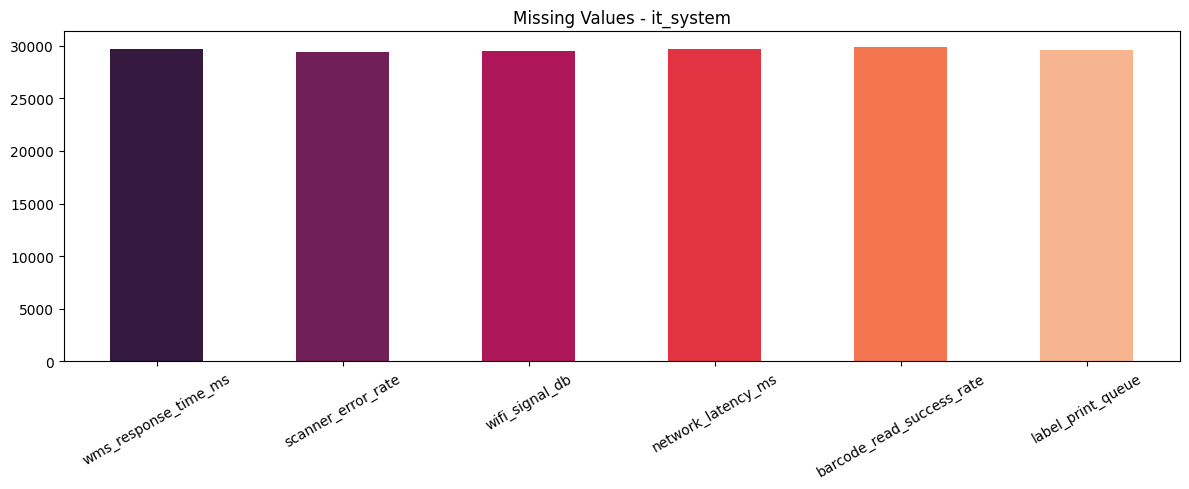

In [6]:
missing = it_system.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - it_system')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
* 상관관계가 없는 것으로 판단

In [7]:
corr = it_system.corr()
corr

,wms_response_time_ms,scanner_error_rate,wifi_signal_db,network_latency_ms,barcode_read_success_rate,label_print_queue
wms_response_time_ms,1.000000,-0.000793,-0.008661,-0.018835,-0.002364,0.018246
scanner_error_rate,-0.000793,1.000000,-0.006295,-0.000288,0.004291,-0.007083
wifi_signal_db,-0.008661,-0.006295,1.000000,-0.013718,0.010185,0.005359
network_latency_ms,-0.018835,-0.000288,-0.013718,1.000000,0.007709,-0.005702
barcode_read_success_rate,-0.002364,0.004291,0.010185,0.007709,1.000000,0.007987
label_print_queue,0.018246,-0.007083,0.005359,-0.005702,0.007987,1.000000


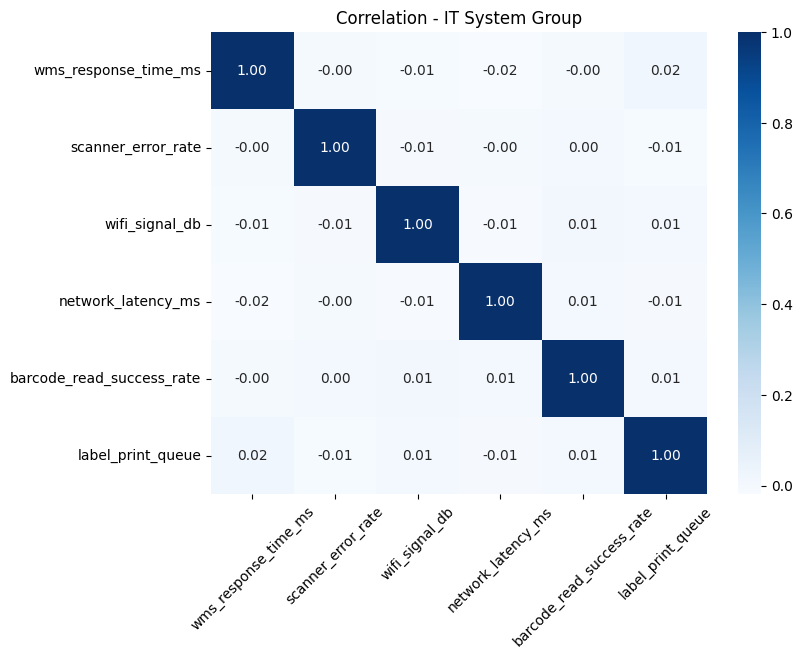

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - IT System Group')
plt.xticks(rotation=45)
plt.show()